In [15]:
from pathlib import Path
import re
import matplotlib.pyplot as plt


def extract_losses(file_path, loss_type="train", scale=1000):
    file_path = Path(file_path)

    if loss_type.lower() == "train":
        pattern = r"Train Loss:\s*([0-9.eE+-]+)"
    elif loss_type.lower() == "test":
        pattern = r"Test Loss:\s*([0-9.eE+-]+)"
    else:
        raise ValueError("loss_type must be either 'train' or 'test'")

    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        text = f.read()

    losses = [
        float(match.group(1)) * scale
        for match in re.finditer(pattern, text)
    ]

    return losses


def clean_label(file_name):
    return (
        Path(file_name).name
        .replace(".log", "")
        .replace("_", " ")
        .replace("att", "attention,")
    )


def plot_losses(file_names, loss_type="train", scale=1000, ylim=None):
    loss_type = loss_type.lower()

    losses_label = loss_type.capitalize()

    plt.figure(figsize=(9, 5))

    for file_name in file_names:
        losses = extract_losses(file_name, loss_type=loss_type, scale=scale)

        if len(losses) == 0:
            print(f"Warning: no {loss_type} losses found in {file_name}")
            continue

        epochs = range(1, len(losses) + 1)
        plt.plot(epochs, losses, label=clean_label(file_name))

    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel(rf"{losses_label} MSE loss [$10^{{-3}}$]", fontsize=14)
    plt.title(f"{losses_label} loss comparison", fontsize=14)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()



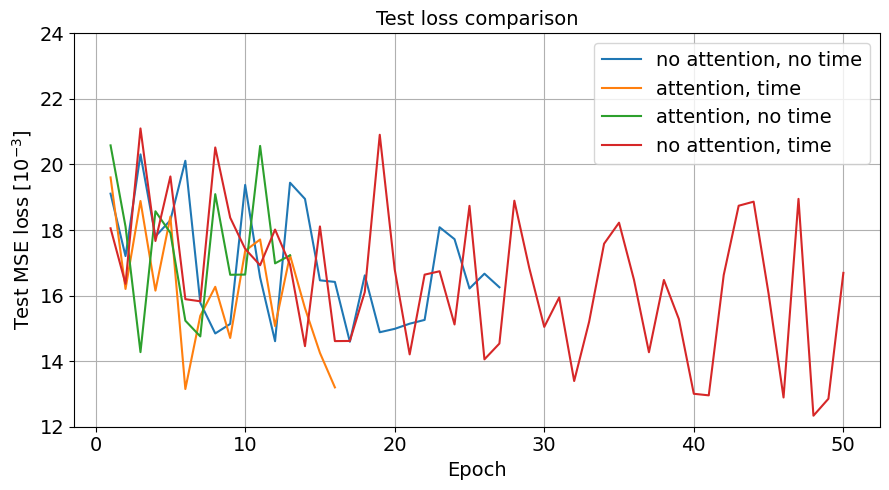

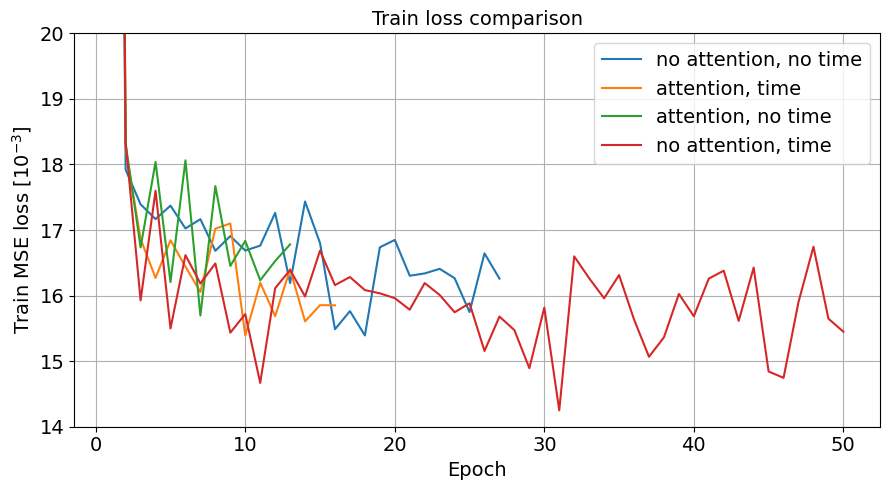

In [16]:
file_names = [
    "no_att_no_time.log",
   "att_time.log",
    "att_no_time.log",
    "no_att_time.log"
]


plot_losses(file_names, loss_type="test", ylim=(12, 24))
plot_losses(file_names, loss_type="train", ylim=(14, 20))